In [117]:
# Importamos pandas porque nos ayuda a leer y organizar los datos en tablas.
import pandas as pd
# También cargamos librerías de gráficos para que los resultados se puedan ver de forma más clara.
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [118]:
# Aquí intentamos abrir el archivo con los datos. Se prueban varias rutas para que el cuaderno funcione sin problema.
possible_paths = [
    r'HR-Employee-Attrition.csv',
    r'WA_Fn-UseC_-HR-Employee-Attrition.csv',
    r'/mnt/data/WA_Fn-UseC_-HR-Employee-Attrition.csv'
]

for path in possible_paths:
    try:
        df_empleados = pd.read_csv(path)
        print(f"Dataset cargado desde: {path}")
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError('No se encontró el dataset en las rutas esperadas.')

df_empleados.head()

# Si el archivo no aparece en esas rutas, basta con cambiar la ruta o colocar el CSV junto al cuaderno.

Dataset cargado desde: HR-Employee-Attrition.csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Informe estadístico del taller

Este cuaderno presenta el desarrollo completo del taller de probabilidad e inferencia estadística aplicado al conjunto de datos **IBM HR Analytics Employee Attrition**. La idea es que pueda leerse como un informe: en cada tarea primero se explica qué se quiere analizar, luego se muestran los resultados obtenidos y finalmente se deja una interpretación breve en lenguaje claro.

Para facilitar la lectura, el código puede mantenerse minimizado. Aun así, cada bloque incluye comentarios sencillos para que se entienda qué se está haciendo y por qué se hace.

## Estructura del informe

El documento está organizado por tareas, desde la **Tarea 1** hasta la **Tarea 18**. En cada una se conserva el hilo del análisis: planteamiento, procedimiento, resultado e interpretación.

## Tarea 1 — Exploración inicial

En esta primera parte se presenta una descripción general de la base de datos. El propósito es entender cuántos registros hay, cómo se distribuye la variable de interés y qué tan equilibrado está el problema de deserción.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [119]:
# Con esto vemos cuántas filas y columnas tiene la base.
# Con esto vemos cuántas filas y cuántas columnas tiene la base.
df_empleados.shape

(1470, 35)

### Tarea 1.b — Frecuencias de Attrition

Primero contamos cuántos empleados se quedaron y cuántos se fueron. Después convertimos esos conteos en proporciones para entender el peso de cada grupo dentro del total.

In [120]:
# Primero contamos cuántos empleados aparecen en cada categoría de Attrition.
df_empleados["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [121]:
# Ahora convertimos esos conteos en proporciones para entender mejor el peso de cada grupo.
# Ahora pasamos esos conteos a proporciones para que la lectura sea más sencilla.
Total = df_empleados["Attrition"].count()

# Se saca el total de registros por cada valor de attrition para calcular la frecuencia relativa.
valoresAtt = df_empleados["Attrition"].value_counts()

# Se sacan los valores de attrition en Yes y No para calcular la frecuencia relativa.
valoresYes = valoresAtt.iloc[1]
valoresNo = valoresAtt.iloc[0]

# Se calcula la frecuencia relativa de cada valor de attrition.
FrecuenciaRelativaYes = valoresYes / Total
FrecuenciaRelativaNo = valoresNo / Total

# Se muestran las frecuencias relativas de cada valor de attrition.
print("Frecuencia Relativa de Attrition = Yes: ", FrecuenciaRelativaYes)
print("Frecuencia Relativa de Attrition = No: ", FrecuenciaRelativaNo)

Frecuencia Relativa de Attrition = Yes:  0.16122448979591836
Frecuencia Relativa de Attrition = No:  0.8387755102040816


### Tarea 1.c — ¿La variable está balanceada?

La variable **Attrition** está claramente desbalanceada: la mayor parte de los registros está en **No**, mientras que **Yes** representa una porción mucho menor del total.

En un ejercicio de clasificación, esto importa porque el modelo podría aprender a favorecer demasiado la clase mayoritaria. Dicho de forma simple, podría “acertar mucho” solo prediciendo que la mayoría se queda, pero fallar justamente en el grupo que más interesa estudiar: quienes desertan.

## Tarea 2 — Tabla de contingencia: OverTime vs Attrition

Aquí se analiza la relación entre las horas extra y la deserción laboral. Primero se revisan las frecuencias observadas y luego se traducen en probabilidades conjuntas, marginales y condicionales para poder comparar mejor ambos fenómenos.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

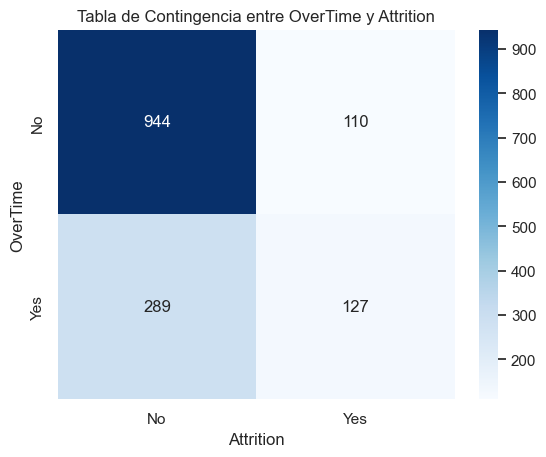

In [122]:
# Cruzamos horas extra y deserción para ver juntas ambas variables.
# Armamos una tabla cruzada para ver juntas las horas extra y la deserción.
tabla = pd.crosstab(df_empleados["OverTime"], df_empleados["Attrition"])

# El mapa de calor ayuda a identificar rápido en qué casillas hay más casos.
sns.heatmap(tabla, cmap="Blues",annot=True,fmt="d")
plt.title("Tabla de Contingencia entre OverTime y Attrition");

### Tarea 2.b — Probabilidades conjuntas

Tomamos la tabla anterior y la llevamos a probabilidades. Así ya no hablamos solo de conteos, sino de qué tan frecuente es cada combinación dentro del total de empleados.

In [123]:
# Pasamos de frecuencias a probabilidades conjuntas.
# Convertimos la tabla en probabilidades conjuntas, es decir, proporciones sobre el total de empleados.
TablaProbConjunta = tabla/tabla.values.sum()
TablaProbConjunta

Attrition,No,Yes
OverTime,,
No,0.642177,0.074830
Yes,0.196599,0.086395


### Tarea 2.c — Probabilidades condicionales

Aquí nos enfocamos en comparar la deserción dentro de cada grupo de horas extra. Esto ayuda mucho a ver si trabajar horas adicionales cambia la probabilidad de irse.

In [124]:
# Ahora calculamos probabilidades condicionales por fila.
# Ahora calculamos probabilidades condicionales por fila para comparar dentro de cada grupo de OverTime. condicionales
tabla.div(tabla.sum(axis=1),axis=0)

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


### Tarea 2.c — Probabilidades marginales

También calculamos las probabilidades marginales, es decir, las probabilidades generales de cada categoría sin condicionar por la otra variable.

In [125]:
# Calculamos las probabilidades marginales a partir de los totales.
# Calculamos los totales para obtener las probabilidades marginales.
total_tabla = tabla.values.sum()

# Se calcula la suma total de cada fila en la tabla de contingencia.
filas_total = tabla.sum(axis=1)

# Se calcula la suma total de cada columna en la tabla de contingencia.
cols_total = tabla.sum(axis=0)

# Se divide la suma total de cada fila por el total de la tabla para obtener la probabilidad de cada valor de Overtime.
prob_Overtime = filas_total / total_tabla

# Se divide la suma total de cada columna por el total de la tabla para obtener la probabilidad de cada valor de Attrition.
prob_Attrition = cols_total / total_tabla

#se suman las probabilidades de cada valor de Overtime y Attrition para verificar que sumen 1.
suma_prob_Overtime = prob_Overtime.sum()
suma_prob_Attrition = prob_Attrition.sum()

print("Probabilidad de Overtime: \n", prob_Overtime)
print("\nProbabilidad de Attrition: \n", prob_Attrition)

print("\nSuma de Probabilidades de Overtime: ", suma_prob_Overtime)
print("Suma de Probabilidades de Attrition: ", suma_prob_Attrition)

Probabilidad de Overtime: 
 OverTime
No     0.717007
Yes    0.282993
dtype: float64

Probabilidad de Attrition: 
 Attrition
No     0.838776
Yes    0.161224
dtype: float64

Suma de Probabilidades de Overtime:  1.0
Suma de Probabilidades de Attrition:  1.0


In [126]:
# Dejamos guardadas las probabilidades condicionales para compararlas con más calma.
# Guardamos esta tabla para usarla luego en la comparación e interpretación.
condicionales = tabla.div(tabla.sum(axis=1),axis=0)

# Se toma la columna de Attrition = Yes para obtener la probabilidad condicional de que un empleado tenga attrition dado que hace overtime o no hace overtime.
condicionales.loc[:,"Yes"]

OverTime
No     0.104364
Yes    0.305288
Name: Yes, dtype: float64

### Tarea 2.d — Comparación de probabilidades

Comparamos la probabilidad de deserción entre quienes hacen horas extra y quienes no. La idea es ver si la diferencia es pequeña o si realmente llama la atención.

In [127]:
# Comparamos la probabilidad de deserción entre quienes sí hacen horas extra y quienes no.
# Aquí comparamos de forma directa la probabilidad de deserción con y sin horas extra.
print("Probabilidad condicional de que un empleado tenga attrition dado que hace overtime o no hace overtime: \n", condicionales.loc[:,"Yes"])

# probabilidad marginal de attrition = yes
print("Probabilidad marginal de attrition = yes: \n", prob_Attrition.loc["Yes"])

Probabilidad condicional de que un empleado tenga attrition dado que hace overtime o no hace overtime: 
 OverTime
No     0.104364
Yes    0.305288
Name: Yes, dtype: float64
Probabilidad marginal de attrition = yes: 
 0.16122448979591836


Se observa que las personas que no realizaron horas extra presentan una menor probabilidad de attrition en comparación con aquellas que sí realizaron overtime. En particular, la probabilidad condicional de attrition para empleados con overtime es aproximadamente del 30%, mientras que para aquellos sin overtime es cercana al 10.4%.

Por otro lado, la probabilidad marginal de attrition es del 16%, lo que indica que, del total de la muestra, el 16% de los empleados experimentaron attrition. Al comparar este valor con las probabilidades condicionales, se evidencia que la proporción de attrition es significativamente mayor en el grupo de empleados que realizan horas extra.

En consecuencia, se puede inferir que el overtime podría estar asociado con un mayor riesgo de attrition. No obstante, esta relación no implica causalidad, ya que pueden existir otros factores que también influyan en la deserción, como se observa en el hecho de que algunos empleados sin overtime también presentan attrition.

### Tarea 2.e — ¿Hay independencia entre OverTime y Attrition?

En este paso revisamos si sería razonable pensar que ambas variables son independientes o si, por el contrario, muestran alguna relación.

In [128]:
# Revisamos si una probabilidad conjunta coincide con el producto de las marginales.
# Verificamos una combinación puntual para revisar si la idea de independencia tiene sentido.
# dividiendo la celda correspondiente de la tabla de contingencia por el total de la tabla.
p_conjunta = tabla.loc["Yes", "Yes"] / total_tabla

# Probabilidad marginal de attrition = yes y de overtime = yes
p_attrition = tabla["Yes"].sum() / total_tabla  
p_overtime = tabla.loc["Yes"].sum() / total_tabla

# Se multiplican las probabilidades marginales de attrition = yes y de overtime = yes para obtener la probabilidad conjunta bajo la suposición de independencia.
p_producto = p_attrition * p_overtime

print("Probabilidad conjunta de que un empleado tenga attrition = yes y haga overtime = yes: ", p_conjunta)
print("Producto de las probabilidades marginales de attrition = yes y de overtime = yes: ", p_producto)

Probabilidad conjunta de que un empleado tenga attrition = yes y haga overtime = yes:  0.08639455782312926
Producto de las probabilidades marginales de attrition = yes y de overtime = yes:  0.04562543384700819


Al comparar la probabilidad conjunta de que un empleado presente *attrition* y realice horas extra (aproximadamente 8%) con el producto de las probabilidades marginales correspondientes (aproximadamente 4%), se observa una diferencia significativa entre ambos valores. Dado que, bajo independencia, debe cumplirse que 

$P(A \cap B) = P(A)\cdot P(B)$ 

Esta discrepancia indica que las variables *Attrition* y *OverTime* no son independientes.

## Tarea 3 — Department vs Attrition

En esta tarea se estudia si la deserción cambia entre departamentos. La comparación permite identificar si algunos grupos parecen tener una mayor salida de empleados que otros.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

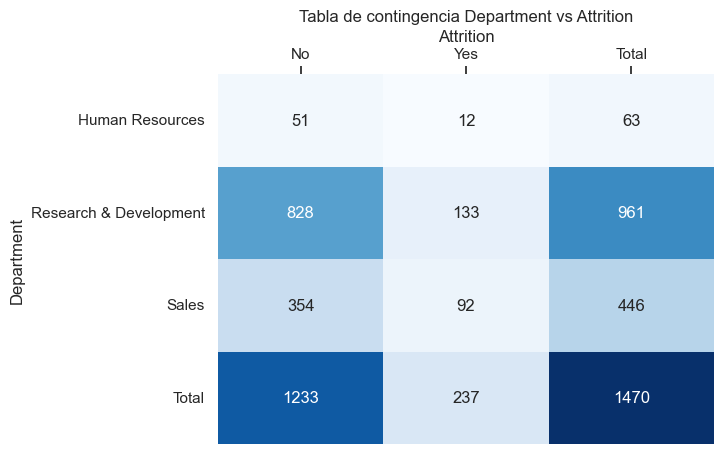

In [129]:
# Hacemos la tabla de frecuencias por departamento y deserción.
# Repetimos el cruce, pero ahora por departamento, para ver cómo cambia la deserción entre áreas.
tabla_d_a = pd.crosstab(df_empleados["Department"], df_empleados["Attrition"],margins=True, margins_name="Total")

# Se guarda el grafico heatmap en la variable ax, con el fin de aplicar propiedades visuales.
ax = sns.heatmap(tabla_d_a, cmap="Blues", annot=True, fmt="d",cbar=False)

ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

plt.title("Tabla de contingencia Department vs Attrition");

### Tarea 3.b — Probabilidades por departamento

Calculamos probabilidades conjuntas, marginales y condicionales para ver cómo cambia la probabilidad de deserción según el departamento.

In [130]:
# Calculamos probabilidades conjuntas para cada combinación departamento-deserción.
tabla_d_a_sin_total = pd.crosstab(df_empleados["Department"], df_empleados["Attrition"])
# Se crea la tabla de probabilidades conjuntas entre Department y Attrition.
TablaProbConjunta_D_A = (tabla_d_a_sin_total/tabla_d_a_sin_total.values.sum())*100
suma_prob_conjunta_D_A = TablaProbConjunta_D_A.values.sum()
print(suma_prob_conjunta_D_A)
TablaProbConjunta_D_A

100.0


Attrition,No,Yes
Department,,
Human Resources,3.469388,0.816327
Research & Development,56.326531,9.047619
Sales,24.081633,6.258503


In [131]:
# A partir de los totales obtenemos las probabilidades marginales.
# Calculamos los totales para obtener las probabilidades marginales.
total_tabla_D_A = tabla_d_a.values.sum()

# Se calcula la suma total de cada fila en la tabla de contingencia.
filas_total_D_A = tabla_d_a.sum(axis=1)

# Se calcula la suma total de cada columna en la tabla de contingencia.
cols_total_D_A = tabla_d_a.sum(axis=0)

# Se divide la suma total de cada fila por el total de la tabla para obtener la probabilidad de cada valor de Overtime.
prob_Department_D_A = filas_total_D_A / total_tabla_D_A

# Se divide la suma total de cada columna por el total de la tabla para obtener la probabilidad de cada valor de Attrition.
prob_Attrition_D_A = cols_total_D_A / total_tabla_D_A

# se imprime la probabilidad conjunta de cada valor de Department y Attrition.
print("Probabilidad de Department: \n", prob_Department_D_A)
print("\nProbabilidad de Attrition: \n", prob_Attrition_D_A)

Probabilidad de Department: 
 Department
Human Resources           0.021429
Research & Development    0.326871
Sales                     0.151701
Total                     0.500000
dtype: float64

Probabilidad de Attrition: 
 Attrition
No       0.419388
Yes      0.080612
Total    0.500000
dtype: float64


In [132]:
# Finalmente calculamos la probabilidad de deserción dentro de cada departamento.
# Esta tabla permite comparar la deserción dentro de cada departamento.
tabla_condicional = tabla_d_a_sin_total.div(tabla_d_a_sin_total.sum(axis=1), axis=0)
tabla_condicional * 100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


### Tarea 3.c — ¿En qué departamento parece ser más probable la deserción?

Con las probabilidades ya calculadas, identificamos el departamento donde la salida de empleados se ve más frecuente.

## Tarea 4 — Regla de la probabilidad total con Department

En esta parte se aplica la regla de la probabilidad total usando como partición los departamentos. La idea es reconstruir la probabilidad global de deserción a partir de lo que ocurre dentro de cada grupo.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [133]:
# Calculamos la probabilidad de pertenecer a cada departamento y la probabilidad de deserción dentro de cada uno.
tabla_t4 = (
    df_empleados
    .groupby('Department')
    .agg(
        P_Bi=('Department', lambda x: len(x) / len(df_empleados)),
        P_A_dado_Bi=('Attrition', lambda x: (x == 'Yes').mean())
    )
)

tabla_t4['Producto'] = tabla_t4['P_Bi'] * tabla_t4['P_A_dado_Bi']
tabla_t4.loc['Total'] = [tabla_t4['P_Bi'].sum(), np.nan, tabla_t4['Producto'].sum()]
tabla_t4.round(4)

,P_Bi,P_A_dado_Bi,Producto
Department,,,
Human Resources,0.0429,0.1905,0.0082
Research & Development,0.6537,0.1384,0.0905
Sales,0.3034,0.2063,0.0626
Total,1.0000,NaN,0.1612


**Comentario.** La suma de la última columna coincide con la probabilidad global de deserción. Esto pasa porque los departamentos separan a todos los empleados en grupos que no se traslapan; por eso, al sumar los aportes de cada grupo, se recupera el total.

## Tarea 5 — Regla de la probabilidad total con JobSatisfaction

Se repite la misma lógica, pero ahora usando los niveles de satisfacción laboral como partición. Esto permite mostrar que la probabilidad total no depende del criterio elegido, siempre que los grupos formen una partición completa.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [134]:
# Repetimos el cálculo, pero ahora usando satisfacción laboral como partición.
tabla_t5 = (
    df_empleados
    .groupby('JobSatisfaction')
    .agg(
        P_Bi=('JobSatisfaction', lambda x: len(x) / len(df_empleados)),
        P_A_dado_Bi=('Attrition', lambda x: (x == 'Yes').mean())
    )
)

tabla_t5['Producto'] = tabla_t5['P_Bi'] * tabla_t5['P_A_dado_Bi']
tabla_t5.loc['Total'] = [tabla_t5['P_Bi'].sum(), np.nan, tabla_t5['Producto'].sum()]
tabla_t5.round(4)

,P_Bi,P_A_dado_Bi,Producto
JobSatisfaction,,,
1,0.1966,0.2284,0.0449
2,0.1905,0.1643,0.0313
3,0.3007,0.1652,0.0497
4,0.3122,0.1133,0.0354
Total,1.0000,NaN,0.1612


**Conclusión.** Sí, vuelve a salir la misma probabilidad global de deserción. No importa si la partición se hace por departamento o por satisfacción laboral: mientras los grupos cubran a toda la población sin repetirse, la regla de la probabilidad total lleva al mismo resultado final.

## Tarea 6 — Teorema de Bayes: ¿de qué departamento proviene quien desertó?

Con la información anterior, ahora el interés cambia: en lugar de preguntar cuál es la deserción dentro de un departamento, se pregunta de qué departamento es más probable que provenga una persona que desertó.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [135]:
# Aplicamos Bayes con los resultados de la Tarea 4.
p_a = (df_empleados['Attrition'] == 'Yes').mean()

tabla_t6 = tabla_t4.drop(index='Total').copy()
tabla_t6['P_Bi_dado_A'] = tabla_t6['Producto'] / p_a

tabla_t6[['P_Bi', 'P_A_dado_Bi', 'Producto', 'P_Bi_dado_A']].round(4)

,P_Bi,P_A_dado_Bi,Producto,P_Bi_dado_A
Department,,,,
Human Resources,0.0429,0.1905,0.0082,0.0506
Research & Development,0.6537,0.1384,0.0905,0.5612
Sales,0.3034,0.2063,0.0626,0.3882


In [136]:
# Verificación directa: contamos dentro del grupo de personas que desertaron.
verificacion_t6 = (
    df_empleados[df_empleados['Attrition'] == 'Yes']['Department']
    .value_counts(normalize=True)
    .rename('Proporcion_dentro_de_Attrition_Yes')
)
verificacion_t6.round(4)

Department
Research & Development    0.5612
Sales                     0.3882
Human Resources           0.0506
Name: Proporcion_dentro_de_Attrition_Yes, dtype: float64

**Comentario.** El departamento con mayor probabilidad a posteriori no siempre tiene la mayor tasa interna de deserción. Puede pasar que un área tenga una tasa moderada, pero como tiene muchísimos empleados, termine aportando más casos de deserción al total.

## Tarea 7 — Bayes aplicado a un clasificador

Esta tarea lleva el teorema de Bayes a un contexto de clasificación. Se usa la sensibilidad, la tasa de falsos positivos y la tasa base para interpretar qué tan confiable es una predicción positiva.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [137]:
# Usamos Bayes para calcular el valor predictivo positivo del modelo.
sensibilidad = 0.80
falsos_positivos = 0.10
tasa_base = 0.1612

ppv = (sensibilidad * tasa_base) / ((sensibilidad * tasa_base) + (falsos_positivos * (1 - tasa_base)))
ppv_50 = (sensibilidad * 0.50) / ((sensibilidad * 0.50) + (falsos_positivos * 0.50))

pd.DataFrame({
    'Escenario': ['Tasa base real del dataset', 'Tasa base hipotética del 50%'],
    'P(Attrition=Yes | Predice Yes)': [ppv, ppv_50]
}).round(4)

,Escenario,P(Attrition=Yes | Predice Yes)
0,Tasa base real del dataset,0.6059
1,Tasa base hipotética del 50%,0.8889


**Interpretación.** Con la tasa base real, una predicción positiva no es tan contundente como podría parecer a primera vista. En cambio, con una tasa base del 50%, la confianza sube bastante. Esta es justamente la idea detrás de la falacia de la tasa base: el rendimiento aparente de un modelo cambia mucho según qué tan frecuente sea el evento en la población.

## Tarea 8 — Verificación empírica del TLC con MonthlyIncome

Aquí se estudia el teorema del límite central con la variable de ingreso mensual. Aunque la distribución original es asimétrica, se espera que las medias muestrales se parezcan cada vez más a una normal a medida que crece el tamaño de muestra.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [138]:
# Preparamos la variable de ingresos y calculamos sus medidas básicas.
income = df_empleados['MonthlyIncome']
mu_income = income.mean()
sigma_income = income.std(ddof=1)

pd.Series({
    'Media MonthlyIncome': mu_income,
    'Desv_est MonthlyIncome': sigma_income,
    'Asimetria MonthlyIncome': income.skew()
}).round(4)

Media MonthlyIncome        6502.9313
Desv_est MonthlyIncome     4707.9568
Asimetria MonthlyIncome       1.3698
dtype: float64

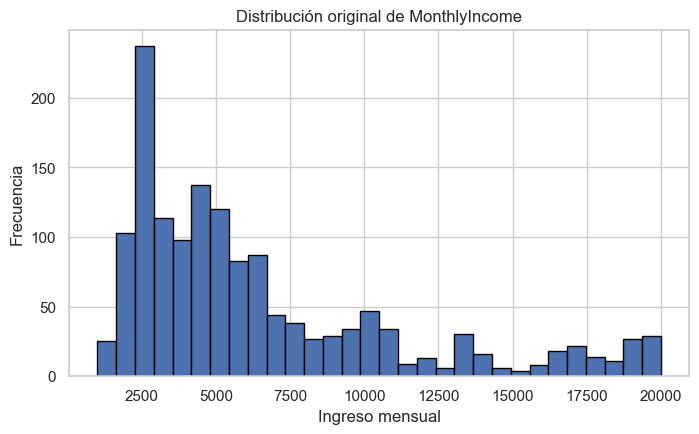

In [139]:
# Primero mostramos la forma original de la variable.
plt.figure(figsize=(8, 4.5))
plt.hist(income, bins=30, edgecolor='black')
plt.title('Distribución original de MonthlyIncome')
plt.xlabel('Ingreso mensual')
plt.ylabel('Frecuencia')
plt.show()

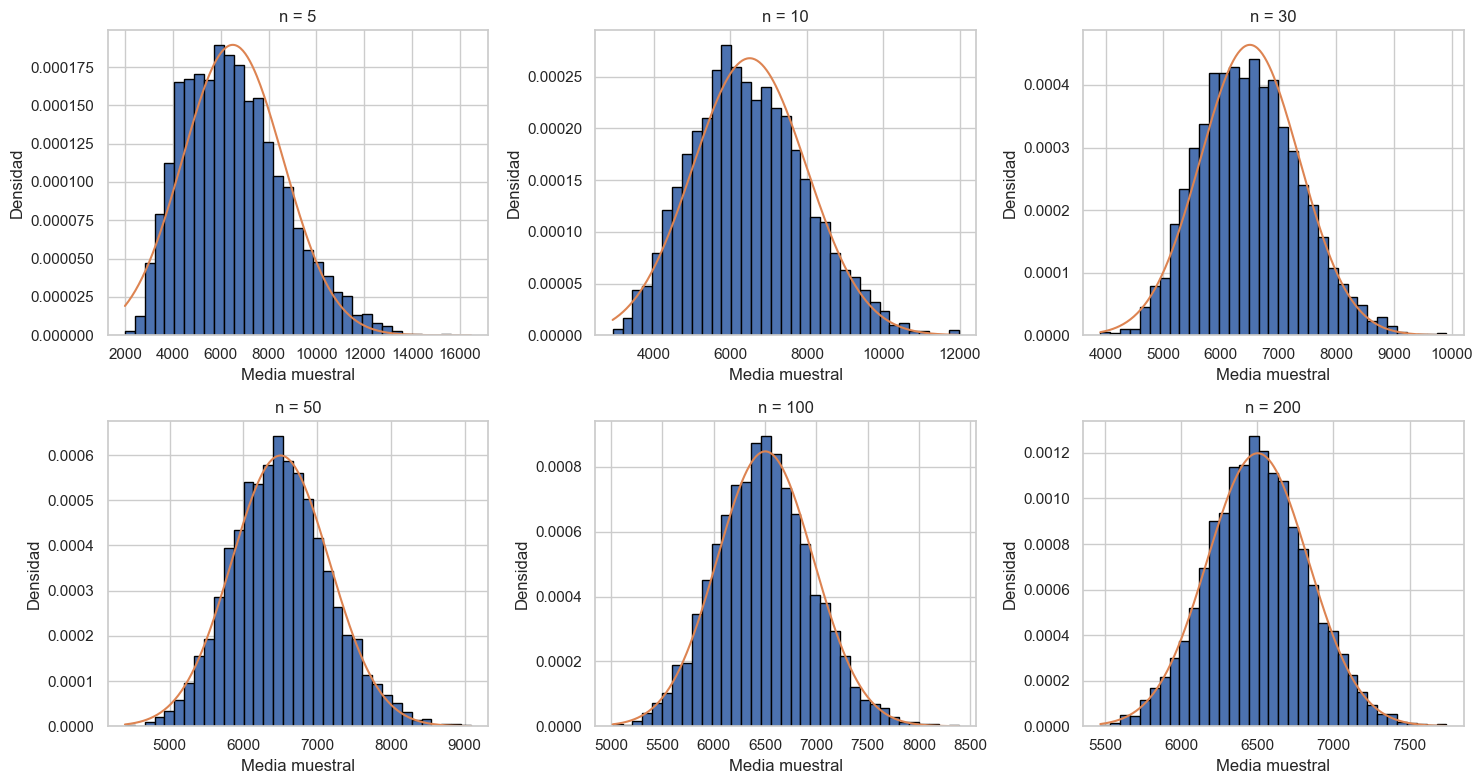

In [140]:
# Simulamos medias muestrales para distintos tamaños de muestra.
from scipy.stats import norm

ns = [5, 10, 30, 50, 100, 200]
B = 5000
resultados_tlc = []

for n_tlc in ns:
    medias = [income.sample(n=n_tlc, replace=True).mean() for _ in range(B)]
    resultados_tlc.append(pd.DataFrame({'n': n_tlc, 'media': medias}))

resultados_tlc = pd.concat(resultados_tlc, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, n_tlc in zip(axes, ns):
    datos_n = resultados_tlc[resultados_tlc['n'] == n_tlc]['media']
    ax.hist(datos_n, bins=35, density=True, edgecolor='black')
    x = np.linspace(datos_n.min(), datos_n.max(), 300)
    ax.plot(x, norm.pdf(x, loc=mu_income, scale=sigma_income / np.sqrt(n_tlc)))
    ax.set_title(f'n = {n_tlc}')
    ax.set_xlabel('Media muestral')
    ax.set_ylabel('Densidad')

plt.tight_layout()
plt.show()

In [141]:
# Comparamos la desviación teórica con la observada en las simulaciones.
tabla_t8 = []
for n_tlc in [5, 30, 100, 200]:
    datos_n = resultados_tlc[resultados_tlc['n'] == n_tlc]['media']
    tabla_t8.append({
        'n': n_tlc,
        'sigma_sobre_raiz_n_teorico': sigma_income / np.sqrt(n_tlc),
        'desv_est_observada': datos_n.std(ddof=1)
    })

pd.DataFrame(tabla_t8).round(4)

,n,sigma_sobre_raiz_n_teorico,desv_est_observada
0,5,2105.4623,2110.4634
1,30,859.5514,872.7320
2,100,470.7957,468.7868
3,200,332.9028,331.7491


**Comentario.** A medida que aumenta el tamaño de la muestra, los histogramas de las medias se vuelven más simétricos y más parecidos a una campana. En este caso, desde tamaños alrededor de 30 o 50 ya se ve una aproximación bastante razonable.

## Tarea 9 — Otra aplicación del TLC y cálculo de probabilidad

En esta sección se compara la velocidad de convergencia entre dos variables y además se usa la aproximación normal para responder una probabilidad concreta sobre la media muestral.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [142]:
# Comparamos la asimetría de ambas variables para discutir cuál converge más rápido.
distancia = df_empleados['DistanceFromHome']

comparacion_asimetria = pd.Series({
    'Asimetria MonthlyIncome': income.skew(),
    'Asimetria DistanceFromHome': distancia.skew()
}).round(4)

comparacion_asimetria

Asimetria MonthlyIncome       1.3698
Asimetria DistanceFromHome    0.9581
dtype: float64

In [143]:
# Calculamos la probabilidad pedida usando la aproximación normal del TLC.
prob_6000_7000 = norm.cdf(7000, loc=mu_income, scale=sigma_income/np.sqrt(50)) - norm.cdf(6000, loc=mu_income, scale=sigma_income/np.sqrt(50))

pd.Series({'P(6000 <= Xbarra <= 7000) con n=50': prob_6000_7000}).round(4)

P(6000 <= Xbarra <= 7000) con n=50    0.5473
dtype: float64

**Interpretación.** La variable con menor asimetría suele acercarse más rápido a la normalidad en sus medias muestrales. Y en la segunda parte, la probabilidad calculada nos dice qué tan probable sería observar una media muestral de ingreso entre 6000 y 7000 dólares cuando se toman muestras de tamaño 50.

## Tarea 10 — Estimaciones puntuales

Esta parte resume varios estimadores importantes del taller, como media, mediana, desviación estándar y proporción. También se interpreta qué dicen estos valores sobre el comportamiento de los datos.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [144]:
# Resumimos varios estimadores importantes en una sola tabla.
attrition_num = (df_empleados['Attrition'] == 'Yes').astype(int)
income_no_t10 = df_empleados.loc[df_empleados['Attrition'] == 'No', 'MonthlyIncome']
income_yes_t10 = df_empleados.loc[df_empleados['Attrition'] == 'Yes', 'MonthlyIncome']

tabla_t10 = pd.DataFrame({
    'Parámetro': [
        'Media de MonthlyIncome',
        'Desviación estándar de MonthlyIncome',
        'Mediana de MonthlyIncome',
        'Proporción de deserción',
        'Diferencia de medias de ingreso (No - Yes)'
    ],
    'Estimador': ['Promedio muestral', 'Desviación muestral', 'Mediana muestral', 'Proporción muestral', 'Diferencia de promedios'],
    'Valor': [
        df_empleados['MonthlyIncome'].mean(),
        df_empleados['MonthlyIncome'].std(ddof=1),
        df_empleados['MonthlyIncome'].median(),
        attrition_num.mean(),
        income_no_t10.mean() - income_yes_t10.mean()
    ]
})

tabla_t10.round(4)

,Parámetro,Estimador,Valor
0,Media de MonthlyIncome,Promedio muestral,6502.9313
1,Desviación estándar de MonthlyIncome,Desviación muestral,4707.9568
2,Mediana de MonthlyIncome,Mediana muestral,4919.0000
3,Proporción de deserción,Proporción muestral,0.1612
4,Diferencia de medias de ingreso (No - Yes),Diferencia de promedios,2045.6468


In [145]:
# Calculamos el error estándar de la proporción de deserción.
p_hat_t10 = attrition_num.mean()
se_p_t10 = np.sqrt(p_hat_t10 * (1 - p_hat_t10) / len(df_empleados))

pd.Series({
    'Proporcion de desercion': p_hat_t10,
    'Error estandar de p_hat': se_p_t10
}).round(4)

Proporcion de desercion    0.1612
Error estandar de p_hat    0.0096
dtype: float64

In [146]:
# También resumimos la antigüedad en la empresa por departamento.
tabla_years_dept = (
    df_empleados
    .groupby('Department')['YearsAtCompany']
    .agg(['mean', 'var'])
    .rename(columns={'mean': 'Media', 'var': 'Varianza'})
)

tabla_years_dept.round(4)

,Media,Varianza
Department,,
Human Resources,7.2381,47.4747
Research & Development,6.8647,36.2900
Sales,7.2848,38.8738


**Comentario final de la Tarea 10.** La comparación entre media y mediana del ingreso ayuda a detectar si la distribución está sesgada. Además, el error estándar de la proporción nos dice qué tanta variabilidad esperaríamos si repitiéramos el muestreo muchas veces.

# Desarrollo del taller

En este cuaderno se organiza la solución del taller con explicaciones, resultados y comentarios escritos en un lenguaje más cercano. La idea no es solo mostrar cuentas, sino dejar claro qué se está haciendo y qué significa cada resultado dentro del problema de deserción laboral.

In [147]:
# Cargamos librerías numéricas y estadísticas que se van a necesitar en las tareas siguientes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, chi2_contingency, ttest_ind, bootstrap

sns.set_theme(style="whitegrid")
np.random.seed(42)

possible_paths = [
    'HR-Employee-Attrition.csv',
]

for path in possible_paths:
    try:
        df = pd.read_csv(path)
        dataset_path = path
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError('No se encontró el dataset en las rutas esperadas.')

print(f'Dataset cargado desde: {dataset_path}')
print(df.shape)

df.head()

Dataset cargado desde: HR-Employee-Attrition.csv
(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Tarea 11 — Intervalo de confianza para la media del ingreso

A partir de los ingresos mensuales se construyen intervalos de confianza para la media poblacional. Se presentan tanto el cálculo paso a paso como la interpretación en contexto.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [148]:
# Reunimos los datos de ingreso y calculamos los elementos básicos del intervalo: promedio, desviación estándar y error estándar.
income = df['MonthlyIncome']
n = income.shape[0]
xbar = income.mean()
s = income.std(ddof=1)
se = s / np.sqrt(n)

levels = [0.90, 0.95, 0.99]
rows = []
for level in levels:
    alpha = 1 - level
    z = norm.ppf(1 - alpha/2)
    li = xbar - z * se
    ls = xbar + z * se
    rows.append({
        'Nivel_confianza': f'{int(level*100)}%',
        'z_critico': z,
        'LI': li,
        'LS': ls,
        'Amplitud': ls - li
    })

ic_media = pd.DataFrame(rows)

print(f'n = {n}')
print(f'Media muestral (x̄) = {xbar:.4f}')
print(f'Desviación estándar muestral (S) = {s:.4f}')
print(f'Error estándar (SE) = {se:.4f}')
print(f'IC 95% manual = ({ic_media.loc[ic_media.Nivel_confianza=="95%", "LI"].iloc[0]:.4f}, {ic_media.loc[ic_media.Nivel_confianza=="95%", "LS"].iloc[0]:.4f})')

ic_media

n = 1470
Media muestral (x̄) = 6502.9313
Desviación estándar muestral (S) = 4707.9568
Error estándar (SE) = 122.7931
IC 95% manual = (6262.2613, 6743.6013)


,Nivel_confianza,z_critico,LI,LS,Amplitud
0,90%,1.644854,6300.954693,6704.907892,403.953200
1,95%,1.959964,6262.261330,6743.601256,481.339926
2,99%,2.575829,6186.637346,6819.225239,632.587893


In [149]:
# Esta celda sirve como verificación: comparamos el cálculo manual con la función de Python.
# Verificación equivalente a la pista de R
ic_t = stats.t.interval(0.95, df=n-1, loc=xbar, scale=se)
pd.Series({'IC 95% con t de Student': ic_t})

IC 95% con t de Student    (6262.062871713204, 6743.79971332081)
dtype: object

### Interpretación de la Tarea 11

Los intervalos cambian según el nivel de confianza: cuando se pide más confianza, el intervalo se hace más ancho. En este caso, el intervalo al 95% ofrece un rango razonable para la media poblacional del ingreso mensual y resume la incertidumbre de la estimación con una lectura clara.

## Tarea 12 — Intervalos para proporciones y diferencia de medias

En esta tarea se construyen intervalos para la proporción de deserción y para la diferencia de ingresos entre quienes se quedaron y quienes desertaron. El interés principal es evaluar si las diferencias observadas parecen ser relevantes.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [150]:
# Empezamos con la proporción general de deserción y su intervalo de confianza al 95%.
# a) IC al 95% para la proporción global de attrition
attr_yes = (df['Attrition'] == 'Yes').sum()
p_hat = attr_yes / len(df)
se_p = np.sqrt(p_hat * (1 - p_hat) / len(df))
z = norm.ppf(0.975)
ic_p = (p_hat - z*se_p, p_hat + z*se_p)

print(f'Proporción muestral de attrition = {p_hat:.4f}')
print(f'IC 95% para p(Attrition=Yes) = ({ic_p[0]:.4f}, {ic_p[1]:.4f})')

Proporción muestral de attrition = 0.1612
IC 95% para p(Attrition=Yes) = (0.1424, 0.1800)


In [151]:
# Luego repetimos la idea por departamento para ver si alguno se aleja del resto.
# b) ICs al 95% por departamento
res_dept = []
for dept, sub in df.groupby('Department'):
    n_dept = len(sub)
    p_dept = (sub['Attrition'] == 'Yes').mean()
    se_dept = np.sqrt(p_dept * (1 - p_dept) / n_dept)
    li = p_dept - z * se_dept
    ls = p_dept + z * se_dept
    res_dept.append({
        'Department': dept,
        'n': n_dept,
        'p_hat': p_dept,
        'LI_95': max(0, li),
        'LS_95': min(1, ls),
        'Ancho': min(1, ls) - max(0, li)
    })

ic_dept = pd.DataFrame(res_dept).sort_values('p_hat', ascending=False)
ic_dept

,Department,n,p_hat,LI_95,LS_95,Ancho
2,Sales,446,0.206278,0.168725,0.243831,0.075105
0,Human Resources,63,0.190476,0.093512,0.287441,0.193929
1,Research & Development,961,0.138398,0.116565,0.160230,0.043665


**Comentario.** Si los intervalos de los departamentos se superponen bastante, conviene ser prudentes: puede haber diferencias visibles en los porcentajes, pero eso no siempre significa que la diferencia sea realmente clara desde el punto de vista estadístico.

In [152]:
# Aquí comparamos el ingreso promedio entre quienes se quedaron y quienes se fueron.
# c) IC al 95% para μ_No - μ_Yes con Welch
income_no = df.loc[df['Attrition'] == 'No', 'MonthlyIncome']
income_yes = df.loc[df['Attrition'] == 'Yes', 'MonthlyIncome']

n1, n2 = len(income_no), len(income_yes)
m1, m2 = income_no.mean(), income_yes.mean()
s1, s2 = income_no.std(ddof=1), income_yes.std(ddof=1)

diff = m1 - m2
se_diff = np.sqrt((s1**2)/n1 + (s2**2)/n2)
nu = ((s1**2/n1 + s2**2/n2)**2) / (((s1**2/n1)**2)/(n1-1) + ((s2**2/n2)**2)/(n2-1))
t_crit = stats.t.ppf(0.975, df=nu)
ic_diff = (diff - t_crit*se_diff, diff + t_crit*se_diff)

pd.Series({
    'Media No': m1,
    'Media Yes': m2,
    'Diferencia (No - Yes)': diff,
    'gl aproximados Welch': nu,
    'IC 95% LI': ic_diff[0],
    'IC 95% LS': ic_diff[1]
})

Media No                 6832.739659
Media Yes                4787.092827
Diferencia (No - Yes)    2045.646832
gl aproximados Welch      412.740748
IC 95% LI                1508.243516
IC 95% LS                2583.050149
dtype: float64

**Interpretación.** Como la resta se definió como **ingreso promedio de quienes se quedan − ingreso promedio de quienes se van**, un intervalo completamente positivo sugiere que quienes permanecen en la empresa ganan más, en promedio.

In [153]:
# Para notar el efecto del tamaño de muestra, repetimos el intervalo con solo 100 observaciones.
# d) Submuestra n = 100 y comparación de anchos
sub100 = df.sample(n=100, random_state=42)['MonthlyIncome']
n100 = len(sub100)
xbar100 = sub100.mean()
s100 = sub100.std(ddof=1)
se100 = s100 / np.sqrt(n100)
ic100 = (xbar100 - z*se100, xbar100 + z*se100)

comparacion_ic = pd.DataFrame({
    'Muestra': ['Completa (n=1470)', 'Submuestra (n=100)'],
    'LI_95': [ic_media.loc[ic_media.Nivel_confianza=='95%', 'LI'].iloc[0], ic100[0]],
    'LS_95': [ic_media.loc[ic_media.Nivel_confianza=='95%', 'LS'].iloc[0], ic100[1]],
    'Ancho': [
        ic_media.loc[ic_media.Nivel_confianza=='95%', 'Amplitud'].iloc[0],
        ic100[1] - ic100[0]
    ]
})
comparacion_ic

,Muestra,LI_95,LS_95,Ancho
0,Completa (n=1470),6262.261330,6743.601256,481.339926
1,Submuestra (n=100),5949.110739,7719.969261,1770.858522


**Conclusión.** La submuestra produce un intervalo más ancho. En palabras simples: con menos datos, la estimación queda menos precisa.

## Tarea 13 — Prueba t: ¿quienes desertan ganan menos?

Ahora se plantea formalmente una prueba de hipótesis para comparar ingresos entre grupos. El objetivo es decidir si hay evidencia estadística de que quienes desertan tienen un ingreso promedio menor.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [154]:
# Aplicamos la prueba t de Welch para revisar si el ingreso de quienes desertan parece menor.
t_stat, p_val_two = ttest_ind(income_no, income_yes, equal_var=False)
# como la hipótesis alternativa es No > Yes, usamos el valor p unilateral
p_val_one = p_val_two / 2 if t_stat > 0 else 1 - (p_val_two / 2)

pd.Series({
    'Estadístico t': t_stat,
    'Valor-p bilateral': p_val_two,
    'Valor-p unilateral (No > Yes)': p_val_one
})

Estadístico t                    7.482622e+00
Valor-p bilateral                4.433589e-13
Valor-p unilateral (No > Yes)    2.216794e-13
dtype: float64

### Interpretación de la Tarea 13

Si el valor-p es pequeño, se concluye que hay evidencia a favor de que quienes desertan ganan menos en promedio. Esta conclusión debe ser coherente con el intervalo de confianza calculado antes: si la diferencia de medias favorece al grupo que permanece, ambas herramientas cuentan la misma historia desde ángulos distintos.

## Tarea 14 — Prueba chi-cuadrado de independencia

En esta parte se evalúa si existe asociación entre variables categóricas, especialmente entre horas extra y deserción, y entre departamento y deserción.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [155]:
# Primero evaluamos la relación entre horas extra y deserción.
# a-b) Attrition vs OverTime
tabla_ot = pd.crosstab(df['OverTime'], df['Attrition'])
chi2_ot, p_ot, gl_ot, exp_ot = chi2_contingency(tabla_ot)

resultado_ot = pd.Series({
    'Chi-cuadrado': chi2_ot,
    'gl': gl_ot,
    'valor-p': p_ot
})
resultado_ot

Chi-cuadrado    8.756429e+01
gl              1.000000e+00
valor-p         8.158424e-21
dtype: float64

In [156]:
# Después hacemos la misma prueba entre departamento y deserción.
# c) Attrition vs Department
tabla_dep = pd.crosstab(df['Department'], df['Attrition'])
chi2_dep, p_dep, gl_dep, exp_dep = chi2_contingency(tabla_dep)

resultado_dep = pd.Series({
    'Chi-cuadrado': chi2_dep,
    'gl': gl_dep,
    'valor-p': p_dep
})
resultado_dep

Chi-cuadrado    10.796007
gl               2.000000
valor-p          0.004526
dtype: float64

### Interpretación de la Tarea 14

La prueba chi-cuadrado permite decidir si las diferencias observadas en la tabla son demasiado grandes como para atribuirlas solo al azar. Un valor-p pequeño sugiere que sí existe asociación entre las variables comparadas.

## Tarea 15 — Prueba para una proporción y reflexión

Aquí se contrasta si la proporción de deserción supera un valor de referencia y luego se compara la edad promedio entre grupos. Al final se discute la diferencia entre encontrar significancia estadística y obtener una diferencia realmente importante en la práctica.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [157]:
# Probamos si la proporción de deserción supera el 15%.
# a) Prueba Z para una proporción
p0 = 0.15
z_prop = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / len(df))
pval_prop = 1 - norm.cdf(z_prop)

pd.Series({
    'p_hat': p_hat,
    'Z': z_prop,
    'valor-p unilateral': pval_prop
})

p_hat                 0.161224
Z                     1.205231
valor-p unilateral    0.114057
dtype: float64

In [158]:
# También comparamos la edad promedio entre quienes desertan y quienes no.
# b) Edad promedio: prueba bilateral entre grupos de attrition
age_no = df.loc[df['Attrition'] == 'No', 'Age']
age_yes = df.loc[df['Attrition'] == 'Yes', 'Age']
t_age, p_age = ttest_ind(age_no, age_yes, equal_var=False)

pd.Series({
    'Media edad No': age_no.mean(),
    'Media edad Yes': age_yes.mean(),
    't bilateral': t_age,
    'valor-p bilateral': p_age
})

Media edad No        3.756123e+01
Media edad Yes       3.360759e+01
t bilateral          5.828012e+00
valor-p bilateral    1.379760e-08
dtype: float64

### Reflexión de la Tarea 15: significancia estadística y significancia práctica

No toda diferencia estadísticamente significativa implica una diferencia importante en la vida real. Con muestras grandes, incluso cambios pequeños pueden dar valores-p bajos. Por eso conviene mirar al mismo tiempo el tamaño de la diferencia, el contexto del problema y no solo la decisión de rechazar o no rechazar la hipótesis nula.

## Tarea 16 — Bootstrap para la mediana del ingreso

Se usa remuestreo bootstrap para estudiar la variabilidad de la mediana del ingreso. Esta técnica permite estimar error estándar, sesgo e intervalo de confianza sin depender tanto de supuestos teóricos.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [159]:
# Generamos muchas remuestras y calculamos la mediana en cada una para estudiar su variabilidad.
B = 10000
income_values = income.to_numpy()
boot_med = np.array([np.median(np.random.choice(income_values, size=len(income_values), replace=True)) for _ in range(B)])

mediana_muestral = np.median(income_values)
se_boot = boot_med.std(ddof=1)
sesgo_boot = boot_med.mean() - mediana_muestral
ic_boot_med = np.quantile(boot_med, [0.025, 0.975])

pd.Series({
    'Mediana muestral': mediana_muestral,
    'SE bootstrap': se_boot,
    'Sesgo bootstrap': sesgo_boot,
    'IC 95% LI': ic_boot_med[0],
    'IC 95% LS': ic_boot_med[1]
})

Mediana muestral    4919.000000
SE bootstrap         104.077597
Sesgo bootstrap        8.321700
IC 95% LI           4737.500000
IC 95% LS           5150.500000
dtype: float64

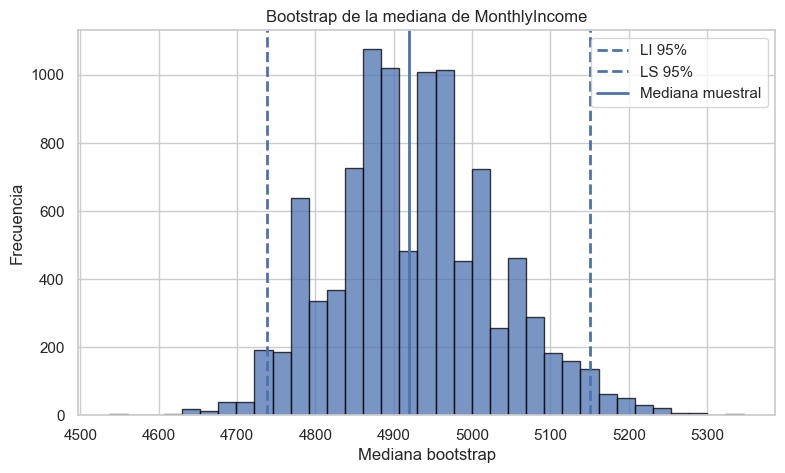

In [160]:
# El histograma bootstrap muestra cómo se distribuyen esas medianas remuestreadas.
plt.figure(figsize=(9,5))
plt.hist(boot_med, bins=35, edgecolor='black', alpha=0.75)
plt.axvline(ic_boot_med[0], linestyle='--', linewidth=2, label='LI 95%')
plt.axvline(ic_boot_med[1], linestyle='--', linewidth=2, label='LS 95%')
plt.axvline(mediana_muestral, linewidth=2, label='Mediana muestral')
plt.title('Bootstrap de la mediana de MonthlyIncome')
plt.xlabel('Mediana bootstrap')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Interpretación de la Tarea 16

Si el sesgo bootstrap resulta pequeño frente al error estándar, eso sugiere que la mediana muestral está funcionando bien como estimador. Además, el intervalo percentil permite ver de manera intuitiva en qué rango suele caer la mediana al repetir el muestreo.

## Tarea 17 — Bootstrap para la diferencia de proporciones

En esta tarea se compara la deserción entre quienes hacen y no hacen horas extra mediante bootstrap. La idea es ver si la diferencia estimada se mantiene lejos de cero al remuestrear muchas veces.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [161]:
# Separamos los grupos por horas extra y remuestreamos cada uno por separado.
ot_yes = (df.loc[df['OverTime'] == 'Yes', 'Attrition'] == 'Yes').astype(int).to_numpy()
ot_no = (df.loc[df['OverTime'] == 'No', 'Attrition'] == 'Yes').astype(int).to_numpy()

boot_diff = np.array([
    np.random.choice(ot_yes, size=len(ot_yes), replace=True).mean() -
    np.random.choice(ot_no, size=len(ot_no), replace=True).mean()
    for _ in range(B)
])

ic_boot_diff = np.quantile(boot_diff, [0.025, 0.975])
obs_diff = ot_yes.mean() - ot_no.mean()

pd.Series({
    'Diferencia observada': obs_diff,
    'IC 95% LI': ic_boot_diff[0],
    'IC 95% LS': ic_boot_diff[1]
})

Diferencia observada    0.200924
IC 95% LI               0.153159
IC 95% LS               0.249003
dtype: float64

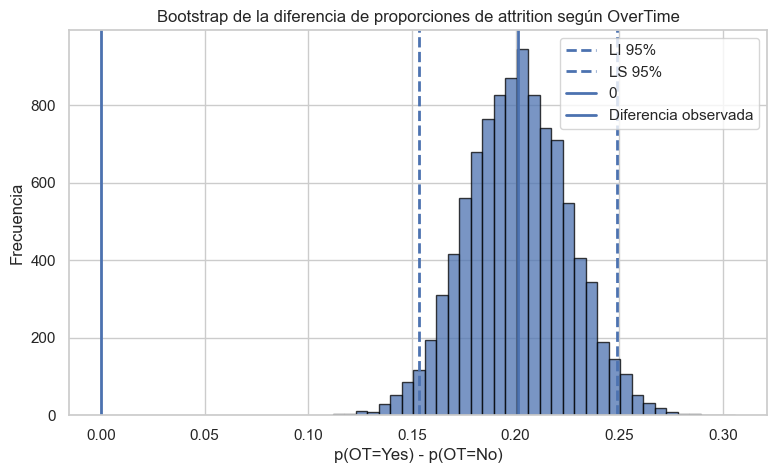

In [162]:
# Graficamos la diferencia bootstrap para ver si el cero queda dentro o fuera del intervalo.
plt.figure(figsize=(9,5))
plt.hist(boot_diff, bins=35, edgecolor='black', alpha=0.75)
plt.axvline(ic_boot_diff[0], linestyle='--', linewidth=2, label='LI 95%')
plt.axvline(ic_boot_diff[1], linestyle='--', linewidth=2, label='LS 95%')
plt.axvline(0, linewidth=2, label='0')
plt.axvline(obs_diff, linewidth=2, label='Diferencia observada')
plt.title('Bootstrap de la diferencia de proporciones de attrition según OverTime')
plt.xlabel('p(OT=Yes) - p(OT=No)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

### Interpretación de la Tarea 17

El punto clave es revisar si el intervalo bootstrap contiene o no el cero. Si no lo contiene, la diferencia entre proporciones parece estable y consistente; si lo contiene, la evidencia es más débil.

## Tarea 18 — Bootstrap BCa y comparaciones

Por último, se construyen intervalos bootstrap más refinados y se comparan con los intervalos paramétricos. También se extiende el remuestreo a otras medidas, como la correlación y el coeficiente de Gini.

**Qué se muestra a continuación.** Se presenta el procedimiento, los resultados principales y una interpretación breve para mantener el hilo del análisis.

In [163]:
# Construimos un intervalo bootstrap BCa para la media del ingreso y lo comparamos con el intervalo clásico.
# a) IC BCa para la media de MonthlyIncome
def stat_mean(x, axis=0):
    return np.mean(x, axis=axis)

res_bca_mean = bootstrap((income_values,), stat_mean, confidence_level=0.95,
                         n_resamples=9999, method='BCa', random_state=42)

pd.Series({
    'Media muestral': income_values.mean(),
    'IC BCa LI': res_bca_mean.confidence_interval.low,
    'IC BCa LS': res_bca_mean.confidence_interval.high
})

Media muestral    6502.931293
IC BCa LI         6270.208110
IC BCa LS         6750.825191
dtype: float64

**Comparación.** Si el IC BCa y el IC paramétrico son muy parecidos, eso sugiere que para la media el enfoque normal funciona bastante bien en este caso. En general, el BCa se prefiere cuando hay asimetría, sesgo o cuando no se desea depender tanto de supuestos paramétricos.

In [164]:
# Aquí estimamos por bootstrap la correlación entre ingreso mensual y años en la empresa.
# c) Bootstrap para la correlación de Pearson
x = df['MonthlyIncome'].to_numpy()
y = df['YearsAtCompany'].to_numpy()

def stat_corr(x, y, axis=-1):
    x = np.asarray(x)
    y = np.asarray(y)
    if axis != -1:
        x = np.moveaxis(x, axis, -1)
        y = np.moveaxis(y, axis, -1)
    x_centered = x - x.mean(axis=-1, keepdims=True)
    y_centered = y - y.mean(axis=-1, keepdims=True)
    num = np.sum(x_centered * y_centered, axis=-1)
    den = np.sqrt(np.sum(x_centered**2, axis=-1) * np.sum(y_centered**2, axis=-1))
    return num / den

res_bca_corr = bootstrap((x, y), stat_corr, paired=True, confidence_level=0.95,
                         n_resamples=9999, method='BCa', random_state=42)

pd.Series({
    'Correlación de Pearson': np.corrcoef(x, y)[0,1],
    'IC BCa LI': res_bca_corr.confidence_interval.low,
    'IC BCa LS': res_bca_corr.confidence_interval.high
})

Correlación de Pearson    0.514285
IC BCa LI                 0.460964
IC BCa LS                 0.563674
dtype: float64

In [165]:
# Como parte opcional, también se estima el coeficiente de Gini del ingreso con bootstrap.
# d) Opcional: coeficiente de Gini por bootstrap
def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    return (2 * np.sum((np.arange(1, n+1)) * x) - (n + 1) * np.sum(x)) / (n * np.sum(x))

def stat_gini(x, axis=0):
    x = np.asarray(x)
    if axis != 0:
        x = np.moveaxis(x, axis, 0)
    if x.ndim == 1:
        return gini(x)
    return np.apply_along_axis(gini, 0, x)

res_bca_gini = bootstrap((income_values,), stat_gini, confidence_level=0.95,
                         n_resamples=9999, method='BCa', random_state=42)

pd.Series({
    'Gini muestral': gini(income_values),
    'IC BCa LI': res_bca_gini.confidence_interval.low,
    'IC BCa LS': res_bca_gini.confidence_interval.high
})

Gini muestral    0.374069
IC BCa LI        0.364957
IC BCa LS        0.383458
dtype: float64

## Cierre del taller

A lo largo del informe se pasó de una exploración descriptiva inicial a herramientas clásicas de inferencia, como intervalos de confianza, pruebas de hipótesis y bootstrap. En conjunto, los resultados permiten entender mejor cómo se comporta la deserción laboral y qué variables parecen relacionarse con ella.

Más allá de los cálculos, la idea central del taller es mostrar que la estadística sirve para sustentar conclusiones con datos, pero también para comunicar esas conclusiones de forma clara y razonada.